In [31]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [4]:
kmean = joblib.load("./kmean-cluster-model.pkl")
kmean

KMeans(n_clusters=3, random_state=42)

In [5]:
data_df = pd.read_csv(r"./processed_household_power_consumption.csv", sep=',')
data_df

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Other_energy_wh,Global_active_power_lag1,Global_active_power_lag24,...,Global_intensity_lag1,Global_intensity_rolling_mean24,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,Global_active_power_rolling_std24,is_weekend_True
0,2.007133,0.126100,243.880667,8.313333,6.866667,0.866667,9.650000,16.068889,3.096833,4.349100,...,12.823333,12.269167,-0.866025,-5.000000e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.282565,True
1,1.686500,0.097833,238.020333,7.130000,0.000000,0.516667,0.000000,27.591667,2.007133,5.452533,...,8.313333,11.592917,-0.965926,-2.588190e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.178259,True
2,0.505200,0.119400,241.156333,2.110000,0.000000,0.600000,0.000000,7.820000,1.686500,3.879400,...,7.130000,10.999028,-1.000000,-1.836970e-16,-0.781831,0.623490,-2.449294e-16,1.000000,1.232380,True
3,0.454033,0.057233,241.419833,1.850000,0.000000,0.000000,0.000000,7.567222,0.505200,4.117833,...,2.110000,10.355278,-0.965926,2.588190e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.258524,True
4,0.474100,0.075367,241.942333,1.956667,0.000000,0.000000,0.000000,7.901667,0.454033,4.181400,...,1.850000,9.703611,-0.866025,5.000000e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.259679,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34393,1.725900,0.061400,237.069667,7.216667,0.000000,0.000000,12.866667,15.898333,1.067933,1.480100,...,4.610000,5.257500,-0.965926,-2.588190e-01,-0.433884,-0.900969,-5.000000e-01,0.866025,0.726796,False
34394,1.573467,0.053700,237.531833,6.620000,0.000000,0.000000,0.000000,26.224444,1.725900,2.211600,...,7.216667,5.144028,-1.000000,-1.836970e-16,-0.433884,-0.900969,-5.000000e-01,0.866025,0.701471,False
34395,1.659333,0.060033,236.741000,7.056667,0.000000,0.066667,0.000000,27.588889,1.573467,2.330467,...,6.620000,5.029722,-0.965926,2.588190e-01,-0.433884,-0.900969,-5.000000e-01,0.866025,0.668173,False
34396,1.163700,0.061167,239.396000,4.913333,0.000000,1.066667,0.000000,18.328333,1.659333,1.647833,...,7.056667,4.950000,-0.866025,5.000000e-01,-0.433884,-0.900969,-5.000000e-01,0.866025,0.661320,False


In [6]:
X = data_df.drop(columns=["is_weekend_True"], errors='coerce')
display(X)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Other_energy_wh,Global_active_power_lag1,Global_active_power_lag24,...,Voltage_lag1,Global_intensity_lag1,Global_intensity_rolling_mean24,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,Global_active_power_rolling_std24
0,2.007133,0.126100,243.880667,8.313333,6.866667,0.866667,9.650000,16.068889,3.096833,4.349100,...,243.182833,12.823333,12.269167,-0.866025,-5.000000e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.282565
1,1.686500,0.097833,238.020333,7.130000,0.000000,0.516667,0.000000,27.591667,2.007133,5.452533,...,243.880667,8.313333,11.592917,-0.965926,-2.588190e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.178259
2,0.505200,0.119400,241.156333,2.110000,0.000000,0.600000,0.000000,7.820000,1.686500,3.879400,...,238.020333,7.130000,10.999028,-1.000000,-1.836970e-16,-0.781831,0.623490,-2.449294e-16,1.000000,1.232380
3,0.454033,0.057233,241.419833,1.850000,0.000000,0.000000,0.000000,7.567222,0.505200,4.117833,...,241.156333,2.110000,10.355278,-0.965926,2.588190e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.258524
4,0.474100,0.075367,241.942333,1.956667,0.000000,0.000000,0.000000,7.901667,0.454033,4.181400,...,241.419833,1.850000,9.703611,-0.866025,5.000000e-01,-0.781831,0.623490,-2.449294e-16,1.000000,1.259679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34393,1.725900,0.061400,237.069667,7.216667,0.000000,0.000000,12.866667,15.898333,1.067933,1.480100,...,240.457833,4.610000,5.257500,-0.965926,-2.588190e-01,-0.433884,-0.900969,-5.000000e-01,0.866025,0.726796
34394,1.573467,0.053700,237.531833,6.620000,0.000000,0.000000,0.000000,26.224444,1.725900,2.211600,...,237.069667,7.216667,5.144028,-1.000000,-1.836970e-16,-0.433884,-0.900969,-5.000000e-01,0.866025,0.701471
34395,1.659333,0.060033,236.741000,7.056667,0.000000,0.066667,0.000000,27.588889,1.573467,2.330467,...,237.531833,6.620000,5.029722,-0.965926,2.588190e-01,-0.433884,-0.900969,-5.000000e-01,0.866025,0.668173
34396,1.163700,0.061167,239.396000,4.913333,0.000000,1.066667,0.000000,18.328333,1.659333,1.647833,...,236.741000,7.056667,4.950000,-0.866025,5.000000e-01,-0.433884,-0.900969,-5.000000e-01,0.866025,0.661320


Using `shap.KernelExplainer` for KMeans


Keep in mind that `KernelExplainer` can be computationally intensive, especially for large datasets. You might consider using a subset of your data `X` for the explainer's background dataset (the first argument) and for generating SHAP values to speed up the process.

Now, let's visualize the SHAP values using a summary plot. Since KMeans outputs cluster assignments, `shap_values_kernel` will be a list where each element corresponds to a cluster, showing the SHAP values for that cluster's prediction.

In [32]:
background = shap.kmeans(X, 50)

def kmeans_distance(X):
  distances = kmean.transform(X)
  return -distances

kernel_explainer = shap.KernelExplainer(kmeans_distance, background)

X_explain = X.sample(1000, random_state=42)
shap_values = kernel_explainer.shap_values(X_explain)

  0%|          | 0/1000 [00:00<?, ?it/s]

SHAP Summary - Cluster 0


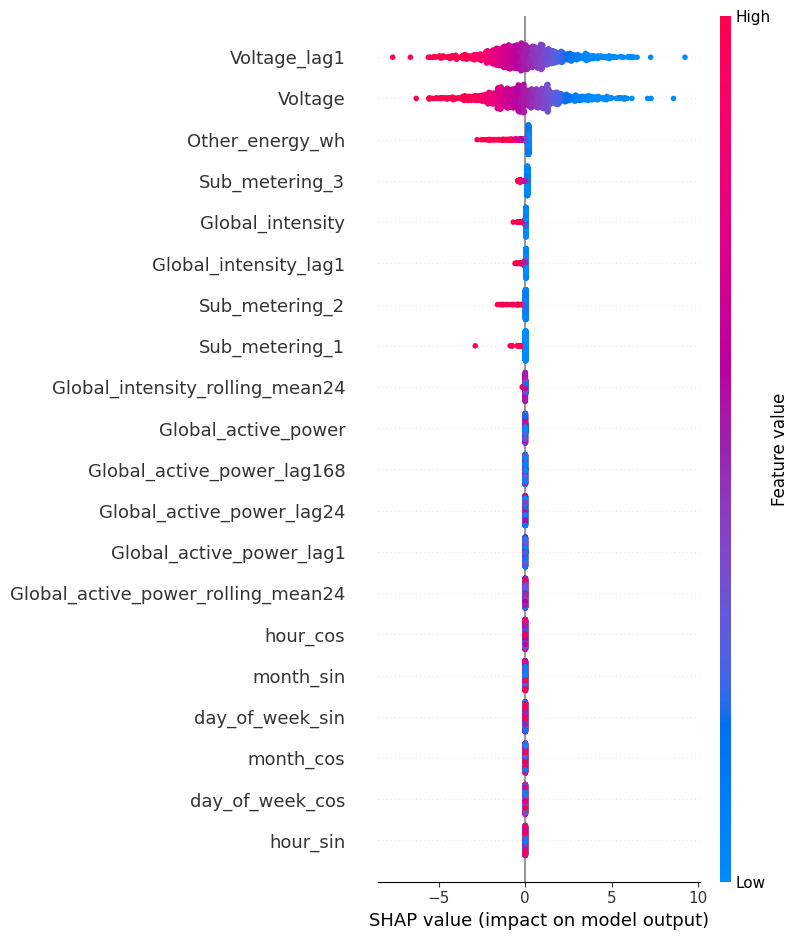

SHAP Summary - Cluster 1


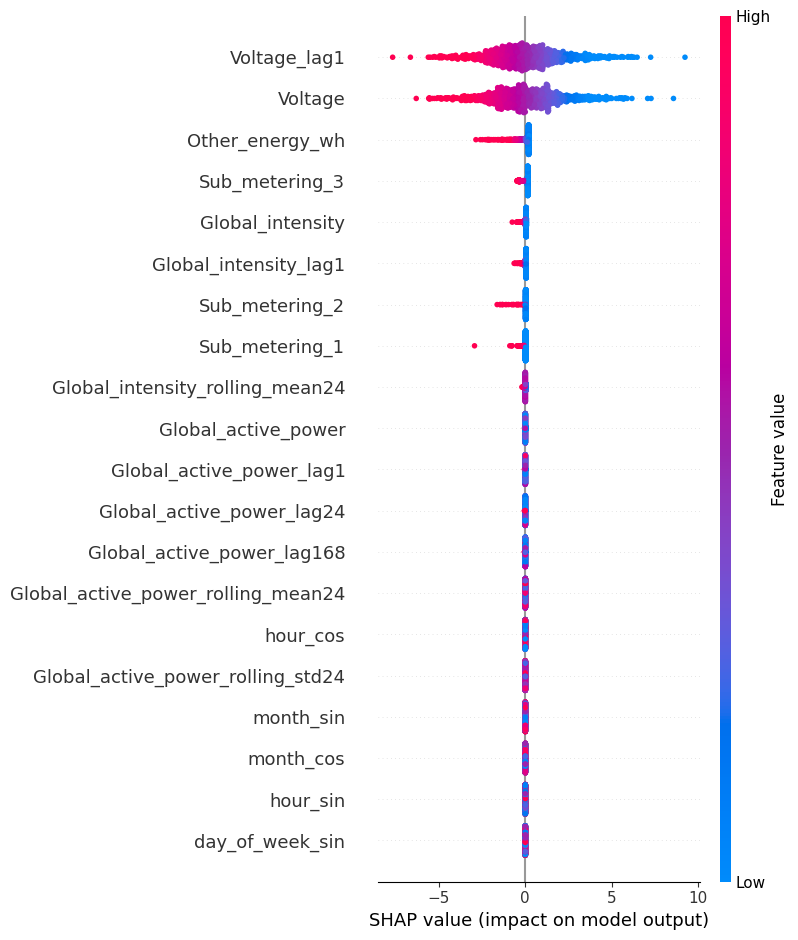

SHAP Summary - Cluster 2


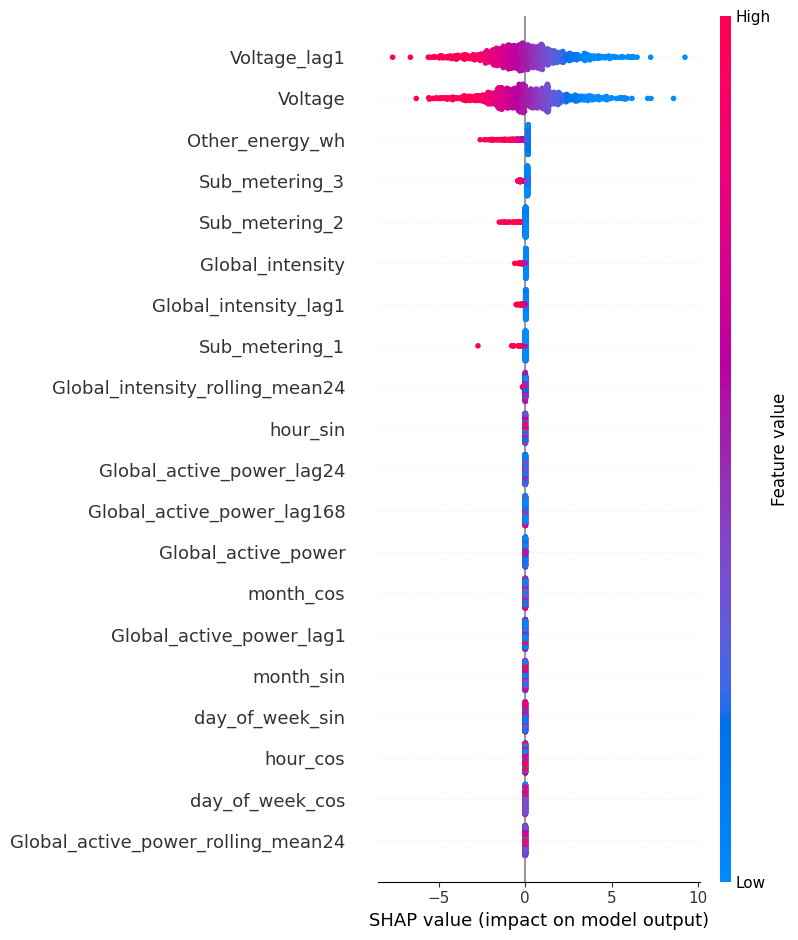

<Figure size 800x500 with 0 Axes>

In [36]:
feature_names = X.columns
for cluster_id in range(kmean.n_clusters):
    print(f"SHAP Summary - Cluster {cluster_id}")
    shap.summary_plot(
        shap_values[:, :, cluster_id],
        X_explain,
        feature_names=feature_names,
        show=True
    )
plt.figure(figsize=(8, 5))
plt.show()

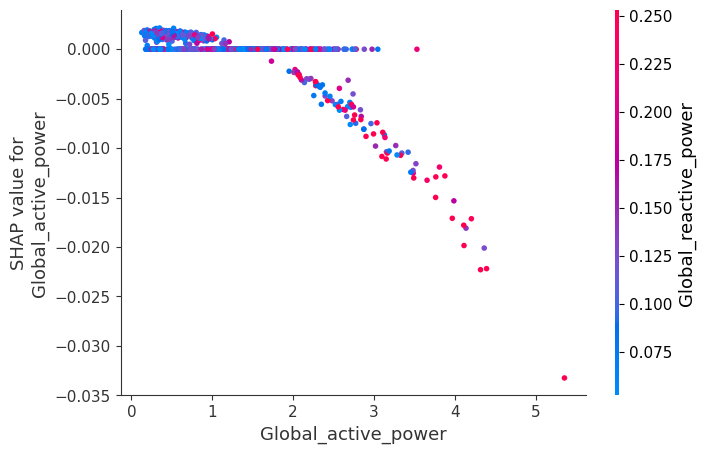

In [40]:
shap.dependence_plot(
    "Global_active_power",
    shap_values[:, :, 0],
    X_explain,
    interaction_index="Global_reactive_power"
)